In [1566]:
#Libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [1567]:
#Load Dataset

df = pd.read_csv('DataSets/used_cars.csv')

In [1568]:
#Read first 5 Rows
df.head()

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
0,Ford,Utility Police Interceptor Base,2013,"51,000 mi.",E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,"$10,300"
1,Hyundai,Palisade SEL,2021,"34,742 mi.",Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,"$38,005"
2,Lexus,RX 350 RX 350,2022,"22,372 mi.",Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,None reported,NaN,"$54,598"
3,INFINITI,Q50 Hybrid Sport,2015,"88,900 mi.",Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,None reported,Yes,"$15,500"
4,Audi,Q3 45 S line Premium Plus,2021,"9,835 mi.",Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,None reported,NaN,"$34,999"


In [1569]:
#Read Last 5 rows
df.tail()

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
4004,Bentley,Continental GT Speed,2023,714 mi.,Gasoline,6.0L W12 48V PDI DOHC Twin Turbo,8-Speed Automatic with Auto-Shift,C / C,Hotspur,None reported,Yes,"$349,950"
4005,Audi,S4 3.0T Premium Plus,2022,"10,900 mi.",Gasoline,349.0HP 3.0L V6 Cylinder Engine Gasoline Fuel,Transmission w/Dual Shift Mode,Black,Black,None reported,Yes,"$53,900"
4006,Porsche,Taycan,2022,"2,116 mi.",NaN,Electric,Automatic,Black,Black,None reported,NaN,"$90,998"
4007,Ford,F-150 Raptor,2020,"33,000 mi.",Gasoline,450.0HP 3.5L V6 Cylinder Engine Gasoline Fuel,A/T,Blue,Black,None reported,Yes,"$62,999"
4008,BMW,X3 xDrive30i,2020,"43,000 mi.",Gasoline,248.0HP 2.0L 4 Cylinder Engine Gasoline Fuel,A/T,Gray,Brown,At least 1 accident or damage reported,Yes,"$40,000"


In [1570]:
#Read Sample Random Data
df.sample(5)

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
2953,Chevrolet,Camaro 1SS,2017,"39,000 mi.",Gasoline,455.0HP 6.2L 8 Cylinder Engine Gasoline Fuel,8-Speed A/T,Yellow,Black,None reported,Yes,"$31,500"
3250,Acura,ILX 2.0L w/Premium Package,2013,"198,000 mi.",Gasoline,150.0HP 2.0L 4 Cylinder Engine Gasoline Fuel,Transmission w/Dual Shift Mode,White,Black,At least 1 accident or damage reported,Yes,"$11,000"
3552,Jeep,Wrangler Sport,2000,"122,945 mi.",Gasoline,181.0HP 4.0L Straight 6 Cylinder Engine Gasoli...,5-Speed M/T,Beige,Brown,None reported,Yes,"$13,900"
1207,Chevrolet,Corvette Base,2004,"43,705 mi.",Gasoline,350.0HP 5.7L 8 Cylinder Engine Gasoline Fuel,6-Speed M/T,Gray,Black,None reported,Yes,"$25,900"
1374,Mercedes-Benz,E-Class E 300 4MATIC,2017,"31,000 mi.",Gasoline,241.0HP 2.0L 4 Cylinder Engine Gasoline Fuel,A/T,Blue,White,At least 1 accident or damage reported,Yes,"$38,000"


In [1571]:
# Check the shape of data means checking the number of rows and cols
df.shape

(4009, 12)

In [1572]:
#Check the full information of dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4009 entries, 0 to 4008
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   brand         4009 non-null   str  
 1   model         4009 non-null   str  
 2   model_year    4009 non-null   int64
 3   milage        4009 non-null   str  
 4   fuel_type     3839 non-null   str  
 5   engine        4009 non-null   str  
 6   transmission  4009 non-null   str  
 7   ext_col       4009 non-null   str  
 8   int_col       4009 non-null   str  
 9   accident      3896 non-null   str  
 10  clean_title   3413 non-null   str  
 11  price         4009 non-null   str  
dtypes: int64(1), str(11)
memory usage: 376.0 KB


In [1573]:
#Check the basic stats of dataset (only of numeric rows)
df.describe()

,model_year
count,4009.000000
mean,2015.515590
std,6.104816
min,1974.000000
25%,2012.000000
50%,2017.000000
75%,2020.000000
max,2024.000000


In [1574]:
# Check the null values in every column using .isna(), Since it returns an object so we use .isna().sum() -> 
df.isna().sum()

brand             0
model             0
model_year        0
milage            0
fuel_type       170
engine            0
transmission      0
ext_col           0
int_col           0
accident        113
clean_title     596
price             0
dtype: int64

In [1575]:
df.dtypes

brand             str
model             str
model_year      int64
milage            str
fuel_type         str
engine            str
transmission      str
ext_col           str
int_col           str
accident          str
clean_title       str
price             str
dtype: object

# Observations(Till now):

- We have total 4009 rows and 12 columns --> 11 input features and one `price` feature we have to predict.
- We have only one column as integer i.e. `model_year` , means we have to extract the numerical data from columns and convert some to integers like `price` and `milage`.
- There are null values in columns -> `fuel_type` -> `170` , `accident` -> `113` , `clean_title` -> `596` which needed to be handled carefully.

In [1576]:
#Creating a copy of dataset to prevent any blunder in the original one.
df_copy = df.copy()

#Data Cleaning
In this step, We will:
- Handles the missing values
- Extract the numeric info from `price` ,`milage` and other columns if any.
- check for duplicates

In [1577]:
#Check for duplicate data points in the Dataset.
df_copy.duplicated().sum()

np.int64(0)

We have Zero Duplicate Value

In [1578]:
# Now handling the missing data of fuel_type.
df_copy['fuel_type'].value_counts(dropna=False)

fuel_type
Gasoline          3309
Hybrid             194
NaN                170
E85 Flex Fuel      139
Diesel             116
–                   45
Plug-In Hybrid      34
not supported        2
Name: count, dtype: int64

In [1579]:
#We can  convert `-` and `not supported` to `NaN` and then fill the null values to mode of the data so as to make the data or fuel_type column more balanced.
df_copy['fuel_type'] = df['fuel_type'].replace(['–', 'not supported'], np.nan)

In [1580]:
#Now filling the fuel_type column with mode.
df_copy['fuel_type'] = df_copy['fuel_type'].fillna(value=df_copy['fuel_type'].mode()[0]) # mode()[0] means the frequent one.

In [1581]:
#Lets verify
df_copy['fuel_type'].value_counts(dropna=False)

fuel_type
Gasoline          3526
Hybrid             194
E85 Flex Fuel      139
Diesel             116
Plug-In Hybrid      34
Name: count, dtype: int64

In [1582]:
#Now Lets handle accident
df_copy['accident'].value_counts(dropna=False)

accident
None reported                             2910
At least 1 accident or damage reported     986
NaN                                        113
Name: count, dtype: int64

In [1583]:
#We can convert the NaN values to None reported only. We can simply use fillna() function...
df_copy['accident'] = df_copy['accident'].fillna(value='None reported')

In [1584]:
#Verify.....
df_copy['accident'].value_counts(dropna=False)

accident
None reported                             3023
At least 1 accident or damage reported     986
Name: count, dtype: int64

In [1585]:
#Now Handle the clean_title..
df['clean_title'].value_counts(dropna=False)

clean_title
Yes    3413
NaN     596
Name: count, dtype: int64

In [1586]:
#We cannot simply say NaN --> No, there may be a chance of NaN->Yes. So, for now let's convert it into Unknown
df_copy['clean_title'] = df_copy['clean_title'].fillna(value='Unknown')

In [1587]:
#verifying.....
df_copy['clean_title'].value_counts(dropna=False)

clean_title
Yes        3413
Unknown     596
Name: count, dtype: int64

#Now let's fetch the numeric data from milage and price

In [1588]:
#check the sample
df_copy[['price' , 'milage']].head()

,price,milage
0,"$10,300","51,000 mi."
1,"$38,005","34,742 mi."
2,"$54,598","22,372 mi."
3,"$15,500","88,900 mi."
4,"$34,999","9,835 mi."


In [1589]:
#Checl their datatype
df_copy[['price' , 'milage']].dtypes

price     str
milage    str
dtype: object

In [1590]:
#removing `$` from `Price` and mi from `milage`

df_copy['price'] = df_copy['price'].str.replace('$' , '' , regex=False).str.replace(',' , '' , regex=False).astype(float)
df_copy['milage'] = df['milage'].str.replace('mi.' , '' ).str.replace(',','').astype(float)
df_copy.head()

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
0,Ford,Utility Police Interceptor Base,2013,51000.0,E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,10300.0
1,Hyundai,Palisade SEL,2021,34742.0,Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,38005.0
2,Lexus,RX 350 RX 350,2022,22372.0,Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,None reported,Unknown,54598.0
3,INFINITI,Q50 Hybrid Sport,2015,88900.0,Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,None reported,Yes,15500.0
4,Audi,Q3 45 S line Premium Plus,2021,9835.0,Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,None reported,Unknown,34999.0


In [1591]:
#Check the unique values of each column
df_copy.nunique()

brand             57
model           1898
model_year        34
milage          2818
fuel_type          5
engine          1146
transmission      62
ext_col          319
int_col          156
accident           2
clean_title        2
price           1569
dtype: int64

In [1592]:
# Check data types
df_copy.dtypes

brand               str
model               str
model_year        int64
milage          float64
fuel_type           str
engine              str
transmission        str
ext_col             str
int_col             str
accident            str
clean_title         str
price           float64
dtype: object

In [1593]:
#Let's check the values count of categorical columns
categorical_cols = [
    'brand',
    'fuel_type',
    'engine',
    'transmission',
    'ext_col',
    'int_col',
    'accident',
    'clean_title'
]

for col in categorical_cols:
    print(f"\n{col}:")
    print(df_copy[col].value_counts().head(15))


brand:
brand
Ford             386
BMW              375
Mercedes-Benz    315
Chevrolet        292
Porsche          201
Audi             200
Toyota           199
Lexus            163
Jeep             143
Land             130
Nissan           116
Cadillac         107
GMC               91
RAM               91
Dodge             90
Name: count, dtype: int64

fuel_type:
fuel_type
Gasoline          3526
Hybrid             194
E85 Flex Fuel      139
Diesel             116
Plug-In Hybrid      34
Name: count, dtype: int64

engine:
engine
2.0L I4 16V GDI DOHC Turbo                               52
355.0HP 5.3L 8 Cylinder Engine Gasoline Fuel             48
420.0HP 6.2L 8 Cylinder Engine Gasoline Fuel             47
–                                                        45
300.0HP 3.0L Straight 6 Cylinder Engine Gasoline Fuel    44
240.0HP 2.0L 4 Cylinder Engine Gasoline Fuel             42
285.0HP 3.6L V6 Cylinder Engine Gasoline Fuel            40
5.7L V8 16V MPFI OHV                          

We have `-` in our `engine` , `int_col` and `ext_col`. We need to handle them also

In [1594]:
for col in ['engine' , 'ext_col' , 'int_col']:
    print(f"{col} : {(df_copy[col] == '–').sum()}")

engine : 45
ext_col : 15
int_col : 133


In [1595]:
#Replace them with Unknown
for col in ['engine' , 'ext_col' , 'int_col']:
    df_copy[col] = df_copy[col].replace('–','Unknown')

In [1596]:
#Verify...
for col in ['engine' , 'ext_col' , 'int_col']:
    print(f"{col} : {(df_copy[col] == '–').sum()}")

engine : 0
ext_col : 0
int_col : 0


# EDA (Exploratory Data Analysis)
- In this we'll see the relationship between columns

In [1597]:
#Again checking the basic stats....
df_copy.describe()

,model_year,milage,price
count,4009.000000,4009.000000,4.009000e+03
mean,2015.515590,64717.551010,4.455319e+04
std,6.104816,52296.599459,7.871064e+04
min,1974.000000,100.000000,2.000000e+03
25%,2012.000000,23044.000000,1.720000e+04
50%,2017.000000,52775.000000,3.100000e+04
75%,2020.000000,94100.000000,4.999000e+04
max,2024.000000,405000.000000,2.954083e+06


#The model_year ranges from 1974 - 2024. So we can calculate the Age of each model in the feature engineering step.

<Axes: xlabel='model_year', ylabel='Count'>

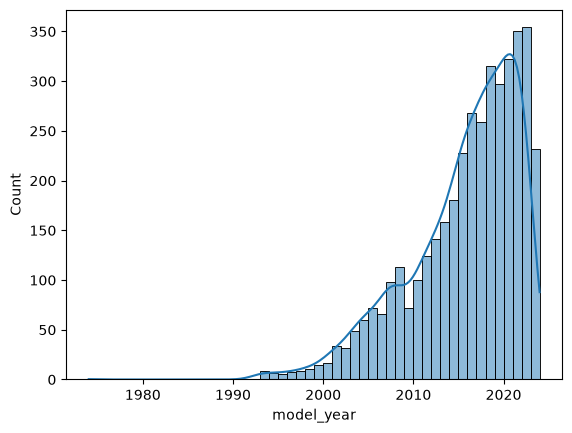

In [1598]:
sns.histplot(df_copy['model_year'] , kde=True)

<Axes: xlabel='price', ylabel='Count'>

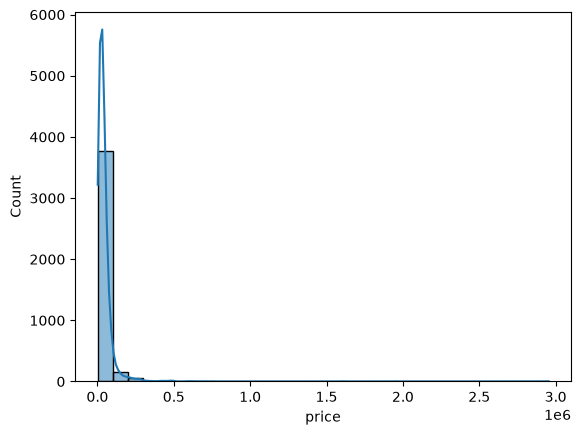

In [1599]:
sns.histplot(df_copy['price'] , bins=30 , kde=True)

LEFT SKEWED


<Axes: xlabel='milage', ylabel='Count'>

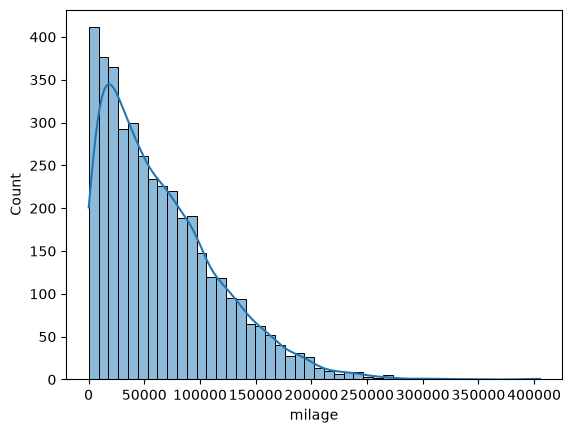

In [1600]:
sns.histplot(df_copy['milage'] , kde=True)

RIGHT SKEWED

Drwaing Scatter Plot to check the relationship between price and other numerical data

<Axes: xlabel='milage', ylabel='price'>

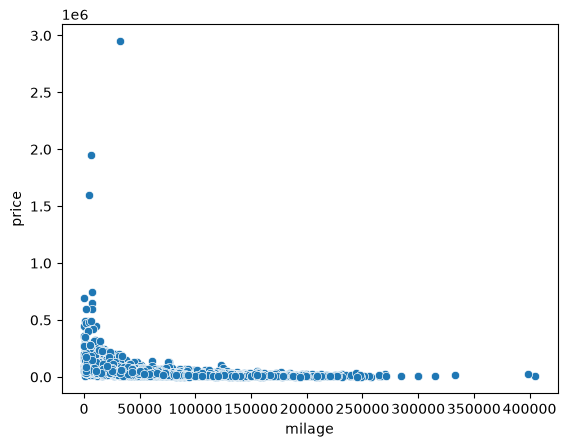

In [1601]:
sns.scatterplot(y = df_copy['price'] , x = df_copy['milage'])

Negative..

<Axes: xlabel='model_year', ylabel='price'>

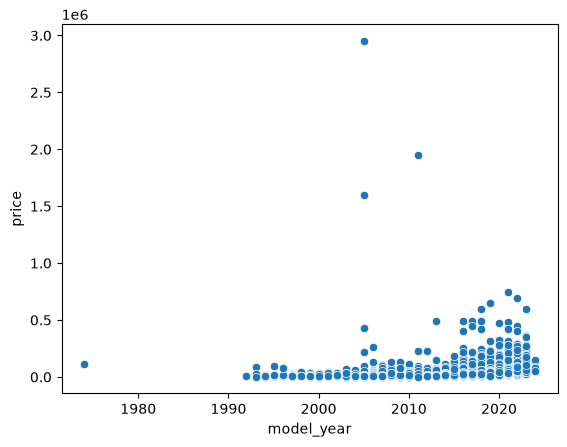

In [1602]:
sns.scatterplot(y = df_copy['price'] , x = df_copy['model_year'])

Positive..

<Axes: >

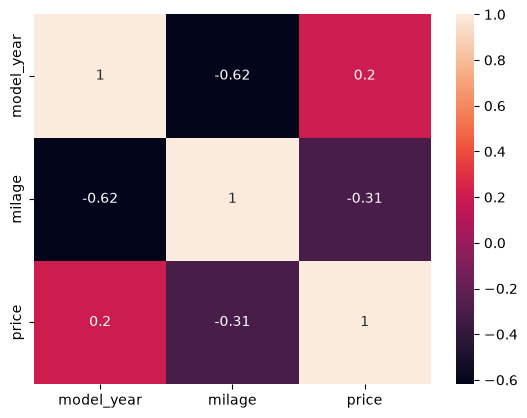

In [1603]:
sns.heatmap(data=df_copy.corr(numeric_only=True) , annot=True)

<Axes: ylabel='brand'>

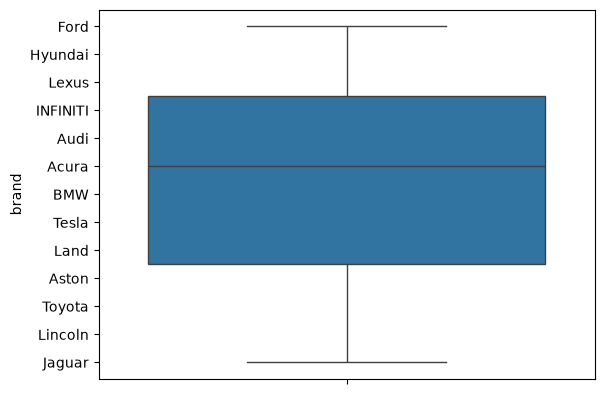

In [1604]:
sns.boxplot(df['brand'].head(15)) # As there are many brands

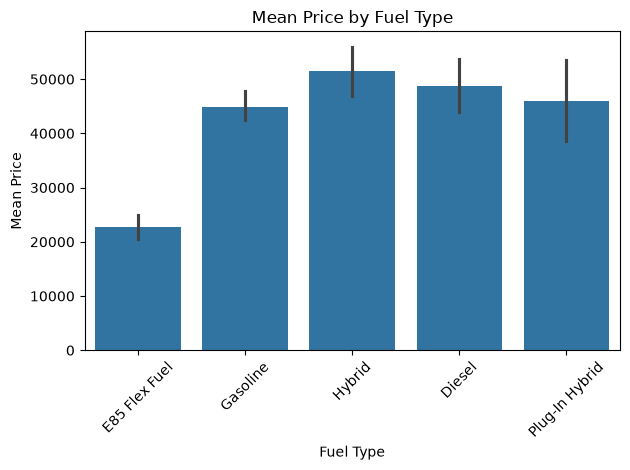

In [1605]:
#We need to check that for every fuel_type what is the average price
sns.barplot(
    data=df_copy,
    x='fuel_type',
    y='price',
    estimator='mean'
)

plt.xlabel('Fuel Type')
plt.ylabel('Mean Price')
plt.title('Mean Price by Fuel Type')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

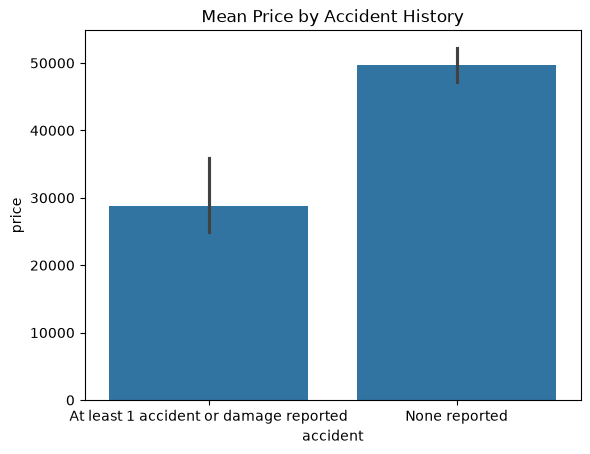

In [1606]:
sns.barplot(data=df_copy , x = 'accident' , y = 'price' , estimator='mean')
plt.title('Mean Price by Accident History')
plt.show()

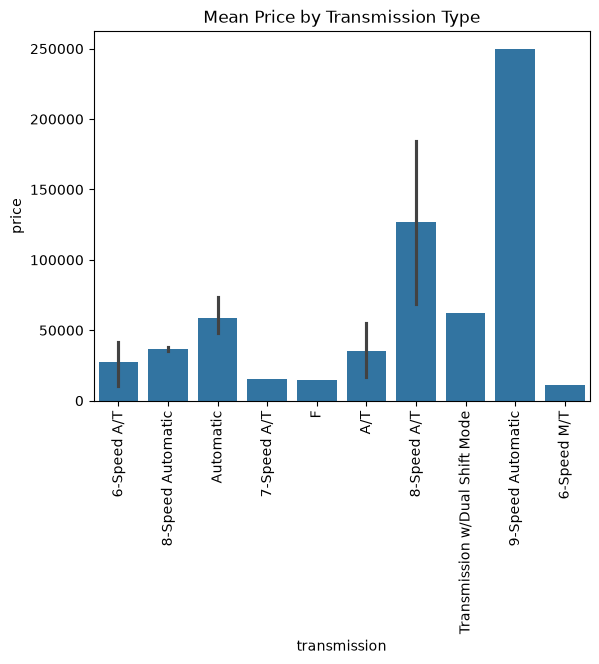

In [1607]:
sns.barplot(data=df_copy.head(20) , x = 'transmission' , y = 'price' , estimator='mean')
plt.title('Mean Price by Transmission Type')
plt.xticks(rotation = 90)
plt.show()

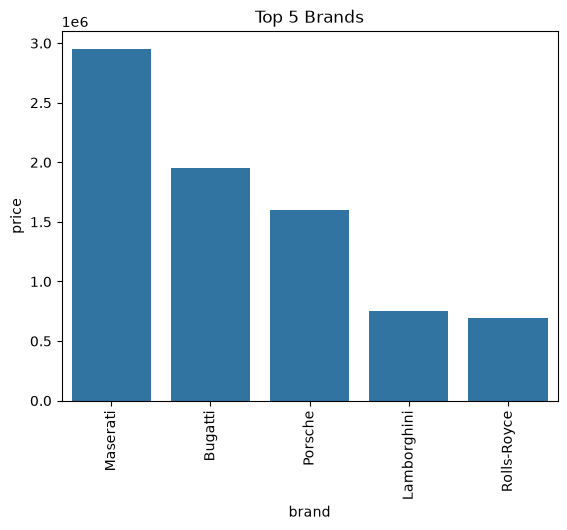

In [1608]:
sns.barplot(data=df_copy.sort_values(by='price' , ascending=False).head(5) , x = 'brand' , y = 'price' , estimator='median')
plt.title('Top 5 Brands')
plt.xticks(rotation = 90)
plt.show()

# Feature Selection & Engg.
- In this step we'll decide which features should actually be used for the Linear Regression model.
- Extract meaningful information from various columns such as `Age` from `model_year` etc..

In [1609]:
#Check all the columns
df_copy.columns

Index(['brand', 'model', 'model_year', 'milage', 'fuel_type', 'engine',
       'transmission', 'ext_col', 'int_col', 'accident', 'clean_title',
       'price'],
      dtype='str')

In [1610]:
#Now split the categorical and numerical features.
categorical_cols = df_copy.select_dtypes(include='object').columns


In [1611]:
numerical_cols = []

for col in df_copy.columns:
    if col not in categorical_cols:
        numerical_cols.append(col)

In [1612]:
#Check the number of unique values from each categorical column
for col in categorical_cols:
    print(col, ":", df_copy[col].nunique())

brand : 57
model : 1898
fuel_type : 5
engine : 1146
transmission : 62
ext_col : 319
int_col : 156
accident : 2
clean_title : 2


In [1613]:
#Check some random data
df_copy.sample(10)

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
357,Mercedes-Benz,Sprinter 4500 High Roof,2019,16813.0,Diesel,188.0HP 3.0L V6 Cylinder Engine Diesel Fuel,Transmission w/Dual Shift Mode,Gray,Black,None reported,Unknown,45900.0
3783,Porsche,Taycan 4S,2022,7900.0,Gasoline,482.0HP Electric Motor Electric Fuel System,2-Speed A/T,Red,Unknown,None reported,Yes,108000.0
829,Mercedes-Benz,GLS 450 Base 4MATIC,2017,46100.0,Gasoline,362.0HP 3.0L V6 Cylinder Engine Gasoline Fuel,9-Speed A/T,Black,Beige,At least 1 accident or damage reported,Yes,33000.0
3709,Ford,Mustang Mach-E Select,2021,18000.0,Gasoline,266.0HP Electric Motor Electric Fuel System,A/T,Blue,Black,None reported,Yes,39499.0
449,BMW,M3 Base,2015,65800.0,Gasoline,425.0HP 3.0L Straight 6 Cylinder Engine Gasoli...,Transmission w/Dual Shift Mode,White,Red,None reported,Yes,44950.0
3586,Land,Rover Range Rover 5.0L Supercharged,2016,64000.0,Gasoline,510.0HP 5.0L 8 Cylinder Engine Gasoline Fuel,Transmission w/Dual Shift Mode,White,White,None reported,Yes,36995.0
1258,Bentley,Continental GTC Base,2013,79422.0,Gasoline,616.0HP 6.0L 12 Cylinder Engine Gasoline Fuel,8-Speed A/T,Black,Black,None reported,Yes,64000.0
3227,Cadillac,Escalade Premium Luxury,2021,11459.0,Gasoline,420.0HP 6.2L 8 Cylinder Engine Gasoline Fuel,10-Speed A/T,White,Brown,None reported,Yes,88900.0
1719,Porsche,Panamera Turbo,2015,67210.0,Gasoline,520.0HP 4.8L 8 Cylinder Engine Gasoline Fuel,Transmission w/Dual Shift Mode,Blue,Beige,At least 1 accident or damage reported,Yes,51950.0
1439,GMC,Yukon XL SLT,2016,93000.0,Gasoline,355.0HP 5.3L 8 Cylinder Engine Gasoline Fuel,A/T,Black,Black,At least 1 accident or damage reported,Yes,30000.0


## My Observations:
- We can extract `engine_capacity` , `engine_power` and `engine_type` from `engine` column.
- We can convert `Transmission` column to `Automatic` and `Manual`.
- We can calculate `Age` from `model_year` as it will bw more useful.

In [1614]:
# Let's first extract age from model_year. We already know the range i.e. 1974 - 2014

df_copy['age'] = df_copy['model_year'].apply(lambda x: 2015 - x)

In [1615]:
#Verifying.... Now we can drop model_year
df_copy.head()

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price,age
0,Ford,Utility Police Interceptor Base,2013,51000.0,E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,10300.0,2
1,Hyundai,Palisade SEL,2021,34742.0,Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,38005.0,-6
2,Lexus,RX 350 RX 350,2022,22372.0,Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,None reported,Unknown,54598.0,-7
3,INFINITI,Q50 Hybrid Sport,2015,88900.0,Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,None reported,Yes,15500.0,0
4,Audi,Q3 45 S line Premium Plus,2021,9835.0,Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,None reported,Unknown,34999.0,-6


In [1616]:
#Now extract various features from engine..

def extract_litre(x):
    try:
        x = x.lower()
        value = x.split('l')[0].split()[-1]
        return float(value)
    except:
        return None

df_copy['engine_capacity'] = df_copy['engine'].apply(extract_litre).astype(float)


In [1617]:
def extract_power(x):
    try:
        value = x.split('HP')[0].split()[-1]
        return float(value)
    except:
        return None

df_copy['engine_power'] = df_copy['engine'].apply(extract_power).astype(float)


In [1618]:
#Verifying...
df_copy.head(5)

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price,age,engine_capacity,engine_power
0,Ford,Utility Police Interceptor Base,2013,51000.0,E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,10300.0,2,3.7,300.0
1,Hyundai,Palisade SEL,2021,34742.0,Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,38005.0,-6,3.8,NaN
2,Lexus,RX 350 RX 350,2022,22372.0,Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,None reported,Unknown,54598.0,-7,3.5,NaN
3,INFINITI,Q50 Hybrid Sport,2015,88900.0,Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,None reported,Yes,15500.0,0,3.5,354.0
4,Audi,Q3 45 S line Premium Plus,2021,9835.0,Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,None reported,Unknown,34999.0,-6,2.0,NaN


In [1619]:
#check null values in those new columns
df_copy[['engine_power' , 'engine_capacity']].isna().sum()

# There are null values because we have converted missing values to unknown

engine_power       808
engine_capacity    220
dtype: int64

In [1620]:
#Filling the null values with the median
df_copy['engine_power'] = df_copy['engine_power'].fillna(df_copy['engine_power'].median())
df_copy['engine_capacity'] = df_copy['engine_capacity'].fillna(df_copy['engine_capacity'].median())

In [1621]:
#Now converting the Transmission Column
df_copy['transmission'].unique()

<StringArray>
[                                                     '6-Speed A/T',
                                                '8-Speed Automatic',
                                                        'Automatic',
                                                      '7-Speed A/T',
                                                                'F',
                                                              'A/T',
                                                      '8-Speed A/T',
                                   'Transmission w/Dual Shift Mode',
                                                '9-Speed Automatic',
                                                      '6-Speed M/T',
                                                     '10-Speed A/T',
                                                      '9-Speed A/T',
                                                      '5-Speed A/T',
                                                      '1-Speed A/T',
                    

In [1622]:
#Function for Extracting Automatic & Manual. I will convert the Ambiguous values to Unknown
def extract_trans(x):
    x = x.lower()

    if 'manual' in x or 'm/t' in x or ' mt' in x:
        return 'Manual'

    elif ('automatic' in x or 
          'a/t' in x or 
          'cvt' in x or 
          'variable' in x or 
          'dct' in x or 
          'dual-clutch' in x):
        return 'Automatic'

    else:
        return 'Unknown'


df_copy['transmission_type'] = df_copy['transmission'].apply(extract_trans)

Now we'll drop some data which i think is not useful like `model_year` because i have already extracted `age`.
I can also drop `engine` and `transmission` because extracted important things.
I'll drop `model`,`ext_col` ,`int_col` because they have many unique values in themselves and has no much relevance

In [1623]:
#Again creating a copy so that my real cleaned data won't get affected by dropping columns
cleaned_data = df_copy.copy()

In [1624]:
cleaned_data = cleaned_data.drop(columns=['engine', 'model_year', 'transmission'  , 'model', 'ext_col', 'int_col'])

In [1625]:
cleaned_data.head()

,brand,milage,fuel_type,accident,clean_title,price,age,engine_capacity,engine_power,transmission_type
0,Ford,51000.0,E85 Flex Fuel,At least 1 accident or damage reported,Yes,10300.0,2,3.7,300.0,Automatic
1,Hyundai,34742.0,Gasoline,At least 1 accident or damage reported,Yes,38005.0,-6,3.8,310.0,Automatic
2,Lexus,22372.0,Gasoline,None reported,Unknown,54598.0,-7,3.5,310.0,Automatic
3,INFINITI,88900.0,Hybrid,None reported,Yes,15500.0,0,3.5,354.0,Automatic
4,Audi,9835.0,Gasoline,None reported,Unknown,34999.0,-6,2.0,310.0,Automatic


Now we'll encode the categorical data using one hot encoding.
Our Categorical Data now are: brand,fuel_type,transmission_type,accident,clean_title

In [1626]:
#One hot Encoding
cleaned_data = pd.get_dummies(cleaned_data , columns=['brand' , 'fuel_type' , 'transmission_type' , 'accident' ,'clean_title'] , drop_first=True , dtype=int)

In [1627]:
cleaned_data.head()

,milage,price,age,engine_capacity,engine_power,brand_Alfa,brand_Aston,brand_Audi,brand_BMW,brand_Bentley,...,brand_Volvo,brand_smart,fuel_type_E85 Flex Fuel,fuel_type_Gasoline,fuel_type_Hybrid,fuel_type_Plug-In Hybrid,transmission_type_Manual,transmission_type_Unknown,accident_None reported,clean_title_Yes
0,51000.0,10300.0,2,3.7,300.0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,1
1,34742.0,38005.0,-6,3.8,310.0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,1
2,22372.0,54598.0,-7,3.5,310.0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,1,0
3,88900.0,15500.0,0,3.5,354.0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,1,1
4,9835.0,34999.0,-6,2.0,310.0,0,0,1,0,0,...,0,0,0,1,0,0,0,0,1,0


In [1628]:
cleaned_data.isna().sum()

milage                       0
price                        0
age                          0
engine_capacity              0
engine_power                 0
                            ..
fuel_type_Plug-In Hybrid     0
transmission_type_Manual     0
transmission_type_Unknown    0
accident_None reported       0
clean_title_Yes              0
Length: 69, dtype: int64

In [1629]:
#Now splitting the input parameters and output parameters
X = cleaned_data.drop(columns=['price'])
y = cleaned_data['price']

In [1630]:
#Now splitting the data for training and testing using train-test-split from skicit learn. 80% training data and 20% testing data.
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

In [1631]:
#Importing and creating the Linear Regression Model

from sklearn.linear_model import LinearRegression
model = LinearRegression()
model

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [1632]:
#Fitting the data
model.fit(X_train , y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](68,)","[ -0.2 ,-2037.99, 9429.81,..., 2670.86, 4817.38, -424.29]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](68,)","['milage','age','engine_capacity',...,'transmission_type_Unknown', 'accident_None reported','clean_title_Yes']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,2.856e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,68
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(50)


In [1633]:
y_pred = model.predict(X_test)

In [1634]:
model.coef_

array([-2.01235671e-01, -2.03799442e+03,  9.42980847e+03,  1.29591313e+01,
       -1.19718137e+04,  2.58873530e+02, -1.28155431e+04, -1.33991300e+04,
        5.19082618e+04,  1.96450856e-10, -2.15272408e+04, -1.69069199e+04,
       -2.78612434e+04, -2.64642457e+04, -2.39262048e+04,  7.73067883e+03,
        1.90295644e+05, -2.16587400e+04, -2.66768477e+04, -2.55290430e+04,
       -9.76354650e+03, -6.02115230e+03, -2.65968517e+04, -2.94799689e+04,
       -2.01503960e+04, -2.16118699e+04,  6.13139995e+02, -2.66369898e+04,
        2.14759491e+05, -4.99923095e+03, -1.64020417e+04, -2.00070812e+04,
        1.47965922e+03, -8.04286723e+02, -1.02008566e+04, -1.27619366e+03,
       -5.14788531e+02, -1.88110427e+04,  1.75440497e+02, -3.63972533e+03,
        6.06565251e+02, -5.79594979e+02, -2.12705182e+04,  3.79284297e+02,
        5.55666722e+02, -5.06598378e+03,  2.79605677e+04, -4.03621975e+04,
        2.05348802e+04,  1.14476723e+04,  8.10993008e+02,  7.30171298e+03,
        1.15049925e+04, -

In [1635]:
model.intercept_

np.float64(28556.387179868307)

In [1636]:
y_pred

array([ 3.91624582e+04, -7.09290928e+02,  4.22550336e+04,  6.22125425e+04,
        6.57642050e+04,  4.01481843e+04,  4.67242286e+04,  7.18867534e+04,
        1.94905722e+04,  5.32434340e+03,  2.99512531e+04,  2.31978557e+04,
        3.60371537e+04,  6.55911824e+04,  4.36738108e+04,  2.90475523e+04,
        5.41817022e+04,  8.54213210e+04,  8.20629457e+03,  5.50728726e+04,
        2.14323926e+04,  3.65241728e+04,  8.19054965e+04,  7.15100043e+04,
        2.90008937e+04,  1.03653465e+04,  8.22455495e+04,  1.90000475e+04,
        1.49363830e+04,  4.02669765e+04,  5.28366613e+04,  6.12039825e+04,
        1.83215426e+04,  3.29083553e+04,  1.34083106e+04, -3.36444798e+03,
       -1.55823968e+04,  5.00477566e+04, -6.74190147e+03,  1.96394761e+04,
        1.58587234e+04,  4.87225230e+04,  1.06072724e+05,  4.46298270e+04,
        7.02320108e+04,  4.39345595e+04,  4.09049294e+04,  5.34436630e+04,
        4.31622611e+04,  1.54623268e+04,  3.59574787e+04,  1.80840111e+04,
        5.40665158e+04, -

In [1637]:
y_test

2580    28000.0
3660     5900.0
897     41000.0
2091    40250.0
1044    77999.0
         ...   
283     54000.0
712     75000.0
274     63000.0
2279    49900.0
621     28000.0
Name: price, Length: 802, dtype: float64

In [1638]:
# import mse, mae, r2_score from sklearn.metrics to evaluate the model performance

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Calculate the metrics
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

In [1639]:
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error(RMSE):" , rmse)
print("Mean Absolute Error (MAE):", mae)
print("R-squared (R2):", r2)

Mean Squared Error (MSE): 18791821929.562847
Root Mean Squared Error(RMSE): 137083.2664097367
Mean Absolute Error (MAE): 25092.23773305423
R-squared (R2): 0.08061564079821071


In [1640]:
#Checking overfitting and underfitting
train_predictions = model.predict(X_train)
test_predictions = model.predict(X_test)
train_r2 = r2_score(y_train, train_predictions)
test_r2 = r2_score(y_test, test_predictions)

print("Training R²:", train_r2)
print("Testing R²:", test_r2)

Training R²: 0.5314529008904476
Testing R²: 0.08061564079821071


Large Gap between both the scores means Overfitting

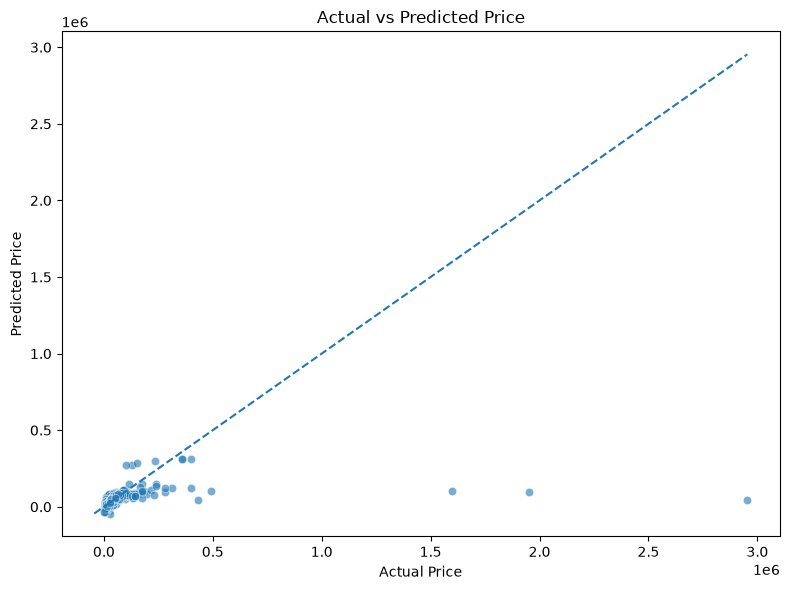

In [1641]:


# Actual vs Predicted plot
plt.figure(figsize=(8, 6))

sns.scatterplot(
    x=y_test,
    y=y_pred,
    alpha=0.6
)

# Perfect prediction line
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle='--'
)

plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted Price')
plt.tight_layout()
plt.show()

# Improvement
- Since the errors are so high and r2 score is so low, we need to improve the model.
- I'll try to re-train the model by adding some dropped columns as `model` , `int_col`  and `ext_col` as they can be useful.

In [1642]:
#Creating new data copy
cleaned_data_new = df_copy.copy()

In [1643]:
cleaned_data_new.drop(columns=['engine', 'model_year', 'transmission'] , inplace = True)

In [1644]:
# One hot Encoding
cleaned_data_new = pd.get_dummies(cleaned_data_new , columns=['brand' , 'fuel_type' , 'transmission_type' , 'accident' ,'clean_title','model' , 'int_col' , 'ext_col'] , drop_first=True , dtype=int)

In [1645]:
# split the input and output parameters
X_new = cleaned_data_new.drop(columns = 'price')
y_new = cleaned_data_new['price']

In [1646]:
#Splitting the data
X_train_new, X_test_new, y_train_new, y_test_new = train_test_split(X_new, y_new, test_size=0.20 , random_state=42)

In [1647]:
#Fitting new Model
model2 = LinearRegression()
model2.fit(X_train_new , y_train_new)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](2438,)","[ -0.18,-1799.05, 6998.55,..., 38.09, 358.93, -191.64]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](2438,)","['milage','age','engine_capacity',...,'ext_col_designo Diamond White', 'ext_col_designo Diamond White Bright', 'ext_col_designo Diamond White Metallic']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,4.714e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,2438
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(106)


In [1648]:
y_pred_new = model2.predict(X_test_new)
y_pred_new

array([ 3.69517990e+04,  7.56177204e+03,  4.54194541e+04,  5.92248936e+04,
        6.71213945e+04,  3.86605433e+04,  4.19353206e+04,  6.40628970e+04,
        1.97486295e+04,  4.12700994e+03,  2.60408311e+04,  2.68337317e+04,
        3.18593898e+04,  6.00018305e+04,  4.54739442e+04,  2.20012909e+04,
        3.06423828e+04,  8.32361955e+04,  7.79375517e+03,  5.58740707e+04,
        2.15394946e+04,  3.43615255e+04,  1.10000049e+05,  7.34986949e+04,
        3.63755716e+04,  9.32880208e+03,  7.47763006e+04,  1.58324951e+04,
        1.19642070e+04,  3.53170693e+04,  4.59196151e+04,  6.09941957e+04,
        1.94760239e+04,  3.10597818e+04,  1.31924348e+04, -2.74843059e+03,
       -1.22877192e+04,  5.90180514e+04,  2.11611664e+03,  2.57933015e+04,
        2.75243834e+04,  5.05628263e+04,  1.14216433e+05,  3.88648822e+04,
        6.86900815e+04,  3.74398756e+04,  2.81678624e+04,  4.97412097e+04,
        4.65640288e+04,  1.90670398e+04,  3.38302505e+04,  1.46746187e+04,
        4.64727345e+04, -

In [1649]:
y_test_new

2580    28000.0
3660     5900.0
897     41000.0
2091    40250.0
1044    77999.0
         ...   
283     54000.0
712     75000.0
274     63000.0
2279    49900.0
621     28000.0
Name: price, Length: 802, dtype: float64

In [1650]:
#Calculate the metrics
mse_new = mean_squared_error(y_test_new, y_pred_new)
rmse_new = np.sqrt(mse_new)
mae_new = mean_absolute_error(y_test_new, y_pred_new)
r2_new = r2_score(y_test_new, y_pred_new)

print("Improved Mean Squared Error (MSE):", mse_new)
print("Improved Root Mean Squared Error(RMSE):" , rmse_new)
print("Improved Mean Absolute Error (MAE):", mae_new)
print("Improved R-squared (R2):", r2_new)

Improved Mean Squared Error (MSE): 18727233426.630722
Improved Root Mean Squared Error(RMSE): 136847.4823540087
Improved Mean Absolute Error (MAE): 23995.933955444045
Improved R-squared (R2): 0.08377561430171854


In [1651]:
#Checking overfitting and underfitting
train_predictions_new = model2.predict(X_train_new)
test_predictions_new = model2.predict(X_test_new)
train_r2_new = r2_score(y_train_new, train_predictions_new)
test_r2_new = r2_score(y_test_new, test_predictions_new)

print("Improved Training R²:", train_r2_new)
print("Improved Testing R²:", test_r2_new)

Improved Training R²: 0.6438518143703955
Improved Testing R²: 0.08377561430171854


Large Gap between both the scores means Overfitting

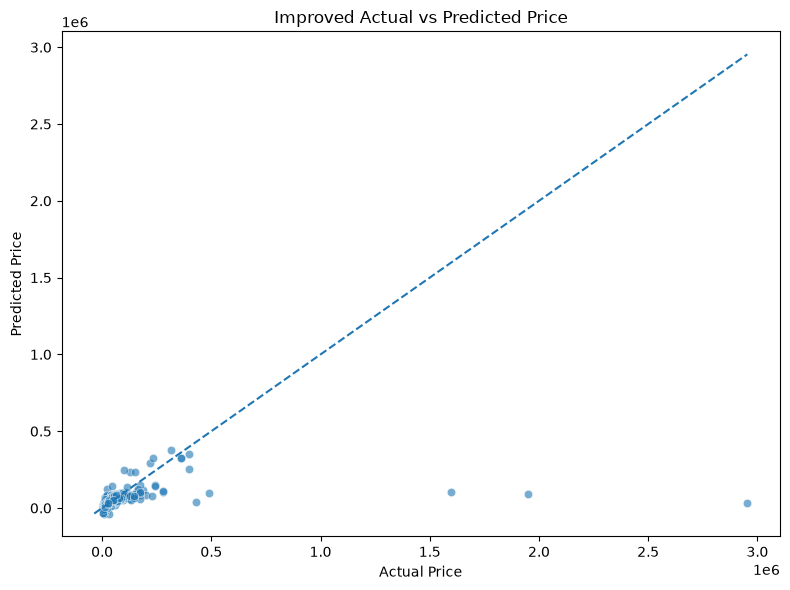

In [1652]:


# Actual vs Predicted plot
plt.figure(figsize=(8, 6))

sns.scatterplot(
    x=y_test_new,
    y=y_pred_new,
    alpha=0.6
)

# Perfect prediction line
min_val = min(y_test_new.min(), y_pred_new.min())
max_val = max(y_test_new.max(), y_pred_new.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle='--'
)

plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Improved Actual vs Predicted Price')
plt.tight_layout()
plt.show()

In [1653]:
print("------Initial Metrics------")
print("mae: " , mae)
print("mse: " , mse)
print("r2: " , r2)
print()

print("-----Improved Metrics------")
print("Improved mae: " , mae_new)
print("Improved mse: " , mse_new)
print("Improved r2: " , r2_new)

------Initial Metrics------
mae:  25092.23773305423
mse:  18791821929.562847
r2:  0.08061564079821071

-----Improved Metrics------
Improved mae:  23995.933955444045
Improved mse:  18727233426.630722
Improved r2:  0.08377561430171854


# NO Drastic Change

# I think we need to Analyze the outliers
- start working with df_copy() again

In [1654]:
#Checking the price column
df_copy['price'].describe()

count    4.009000e+03
mean     4.455319e+04
std      7.871064e+04
min      2.000000e+03
25%      1.720000e+04
50%      3.100000e+04
75%      4.999000e+04
max      2.954083e+06
Name: price, dtype: float64

We can observe  mean >> median  and maximum is very higher so it's `Right_Skewed`

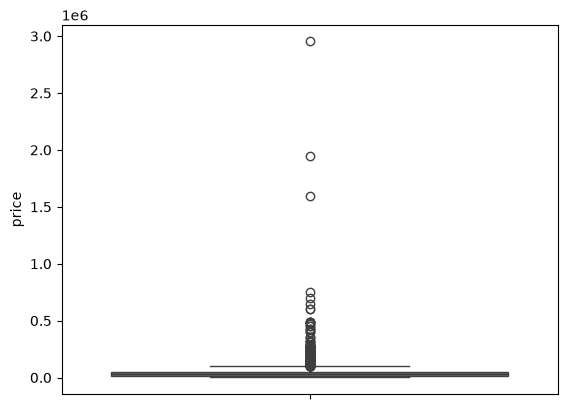

In [1655]:
#Creating the box plot to see the outliers
sns.boxplot(y=df_copy['price'])
plt.show()

Almost all prices are concentrated near the bottom, while there are many points far above the upper.
These are `high price Outliers`

In [1656]:
#Check the max price
df_copy['price'].max()

np.float64(2954083.0)

In [1657]:
#Check the min price
df_copy['price'].min()

np.float64(2000.0)

In [1658]:
df_copy['price'].mean()

np.float64(44553.190321776005)

As we can see the minimum price is 2000 and maximum is 20Lakh and average is 45k. So the errors and r2 score coming is justified

In [1659]:
df_copy['price'].median()

np.float64(31000.0)

Mean median se kaafi zyada hai, which confirms that high-price cars are pulling the average upward. So outliers are affecting the dataset.

In [1660]:
# CHecking  the number of cars priced abovr 1 Lakh using shape since shape return tuple of row and columns we need only rows
df_copy[df_copy['price'] > 100000].shape[0]

234

- 234 cars are priced above $100,000.
- That's about 5.8% of the dataset

In [1661]:
# Now check for car above 5Lakhs
df_copy[df_copy['price'] > 500000].shape[0]

8

This tells us the extremely high prices are in a very small number of cars.

In [1662]:
#Let's check the most 10 expensive cars
df_copy['price'].sort_values(ascending=False).head(10)

693     2954083.0
229     1950995.0
3046    1599000.0
1356     749950.0
624      695000.0
979      649999.0
1615     599995.0
1508     599000.0
3655     491836.0
1061     489995.0
Name: price, dtype: float64

- Most prices are much closer to $2K–$50K
- But the top values suddenly jump to 4Lakh to 29 Lakhs.

In [1663]:
#Check the full row with the maximum price
df_copy.loc[df_copy['price'].idxmax()]

brand                                                    Maserati
model                                           Quattroporte Base
model_year                                                   2005
milage                                                    32000.0
fuel_type                                                Gasoline
engine               394.0HP 4.2L 8 Cylinder Engine Gasoline Fuel
transmission                       Transmission w/Dual Shift Mode
ext_col                                                       Red
int_col                                                     Beige
accident                   At least 1 accident or damage reported
clean_title                                                   Yes
price                                                   2954083.0
age                                                            10
engine_capacity                                               4.2
engine_power                                                394.0
transmissi

In [1664]:
#Cars above 10Lakhs
df_copy[df_copy['price'] > 1000000].shape[0]

3

In [1665]:
#This shows the details of all 3 cars above $1M
df_copy[df_copy['price'] > 1000000][
    ['price', 'brand', 'model', 'model_year', 'milage']
]

,price,brand,model,model_year,milage
229,1950995.0,Bugatti,Veyron 16.4 Grand Sport,2011,6330.0
693,2954083.0,Maserati,Quattroporte Base,2005,32000.0
3046,1599000.0,Porsche,Carrera GT Base,2005,4400.0


In [1666]:
#Remove the highest outlier price car
df_without_maserati = df_copy[df_copy['price'] != 2954083.0]

print("Original rows:", len(df_copy))
print("Rows after removing Maserati:", len(df_without_maserati))

Original rows: 4009
Rows after removing Maserati: 4008


In [1667]:
#Check the max again
df_without_maserati['price'].max()

np.float64(1950995.0)

In [1668]:
df_without_maserati['price'].sort_values(ascending=False).head(10)

229     1950995.0
3046    1599000.0
1356     749950.0
624      695000.0
979      649999.0
1615     599995.0
1508     599000.0
3655     491836.0
1061     489995.0
1148     489000.0
Name: price, dtype: float64

- These are all recognizable luxury/exotic cars, so we shouldn't remove.
- The Maserati was the strongest suspicious record.

In [1669]:
df_without_maserati.shape

(4008, 16)

In [1670]:
# Check missing values
df_without_maserati.isnull().sum()

brand                0
model                0
model_year           0
milage               0
fuel_type            0
engine               0
transmission         0
ext_col              0
int_col              0
accident             0
clean_title          0
price                0
age                  0
engine_capacity      0
engine_power         0
transmission_type    0
dtype: int64

In [1671]:
#Check duplicate
df_without_maserati.duplicated().sum()

np.int64(0)

In [1672]:
#Check datatypes
df_without_maserati.dtypes

brand                    str
model                    str
model_year             int64
milage               float64
fuel_type                str
engine                   str
transmission             str
ext_col                  str
int_col                  str
accident                 str
clean_title              str
price                float64
age                    int64
engine_capacity      float64
engine_power         float64
transmission_type        str
dtype: object

In [1673]:
#Drop irrelevant features
df_without_maserati.drop(columns = ['model_year' , 'engine' , 'transmission'] , inplace=True)

In [1674]:
#Splitting numerical and categorical data
X_clean = df_without_maserati.drop('price', axis=1)
y_clean = df_without_maserati['price']

print("Input :", X_clean.shape)
print("Target:", y_clean.shape)

Input : (4008, 12)
Target: (4008,)


In [1675]:
X_clean_encode =  pd.get_dummies(X_clean , drop_first=True , dtype=int)
print(X_clean_encode.shape)

(4008, 2438)


In [1676]:
#Splitting the data into trainig and testing
X_train_clean, X_test_clean, y_train_clean, y_test_clean = train_test_split(X_clean_encode,y_clean,test_size=0.20,random_state=42)

In [1677]:
#Fit the model

model3 = LinearRegression()

model3.fit(X_train_clean, y_train_clean)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](2438,)","[ -0.2 ,-1913.2 , 7405.33,..., 6431.05, 7793.33, 2120.39]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](2438,)","['milage','age','engine_capacity',...,'clean_title_Yes', 'transmission_type_Manual','transmission_type_Unknown']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,4.375e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,2438
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(109)


In [1678]:
y_pred_clean = model3.predict(X_test_clean)

print(y_pred_clean[:5])

[12419.79953886  1225.46881908 26517.3343177  31715.17724332
 85574.81590756]


In [1679]:
#Calculating the metrics
mae_clean = mean_absolute_error(y_test_clean, y_pred_clean)
mse_clean = mean_squared_error(y_test_clean, y_pred_clean)
rmse_clean = np.sqrt(mse_clean)
r2_clean = r2_score(y_test_clean, y_pred_clean)

print("MAE:", mae_clean)
print("MSE:", mse_clean)
print("RMSE:", rmse_clean)
print("R²:", r2_clean)

MAE: 19944.073979028035
MSE: 7852637155.063851
RMSE: 88615.10681065533
R²: 0.18584974548810185


As it's also not satisfactory.
Need to remove all the outliers high priced ones

In [1680]:
#Fetching the cars having price less that 1Lakh
df_high_outliers_removed = df_without_maserati[
    df_without_maserati['price'] <= 100000
].copy()

print("Original rows:", len(df_without_maserati))
print("Rows after removing high-price cars:", len(df_high_outliers_removed))

Original rows: 4008
Rows after removing high-price cars: 3775


In [1681]:
#Split the input and target
X_outlier_clean = df_high_outliers_removed.drop('price', axis=1)
y_outlier_clean = df_high_outliers_removed['price']


In [1682]:
#one hot encoding
X_outlier_encoded = pd.get_dummies(X_outlier_clean,drop_first=True)

print(X_outlier_encoded.shape)

(3775, 2267)


In [1683]:
#Splitting into training and testing data
X_train_outlier, X_test_outlier, y_train_outlier, y_test_outlier = train_test_split(
    X_outlier_encoded,
    y_outlier_clean,
    test_size=0.20,
    random_state=42
)


In [1684]:
model4 = LinearRegression()

model4.fit(X_train_outlier, y_train_outlier)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](2267,)","[ -0.14,-1169.1 , 2928.22,...,-1268.97, 4073.48, -258.1 ]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](2267,)","['milage','age','engine_capacity',...,'clean_title_Yes', 'transmission_type_Manual','transmission_type_Unknown']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,2.399e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,2267
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(105)


In [1685]:
y_pred_outlier = model4.predict(X_test_outlier)

print(y_pred_outlier[:5])

[17022.45921772 66147.45350659 67339.90793043 19707.19294988
 54099.6199482 ]


In [1686]:
mae_outlier = mean_absolute_error(y_test_outlier, y_pred_outlier)
mse_outlier = mean_squared_error(y_test_outlier, y_pred_outlier)
rmse_outlier = np.sqrt(mse_outlier)
r2_outlier = r2_score(y_test_outlier, y_pred_outlier)

print("MAE:", mae_outlier)
print("MSE:", mse_outlier)
print("RMSE:", rmse_outlier)
print("R²:", r2_outlier)

MAE: 8288.281306868668
MSE: 123054811.65231255
RMSE: 11093.007331301667
R²: 0.7337233453513501


In [1687]:
y_train_pred_outlier = model4.predict(X_train_outlier)

train_r2_outlier = r2_score(
    y_train_outlier,
    y_train_pred_outlier
)

print("Improved Training R²:", train_r2_outlier)
print("Improved Testing R²:", r2_outlier)

Improved Training R²: 0.746806423913694
Improved Testing R²: 0.7337233453513501


Removing the extreme high-price cars significantly improved the Linear Regression model and reduced overfitting.

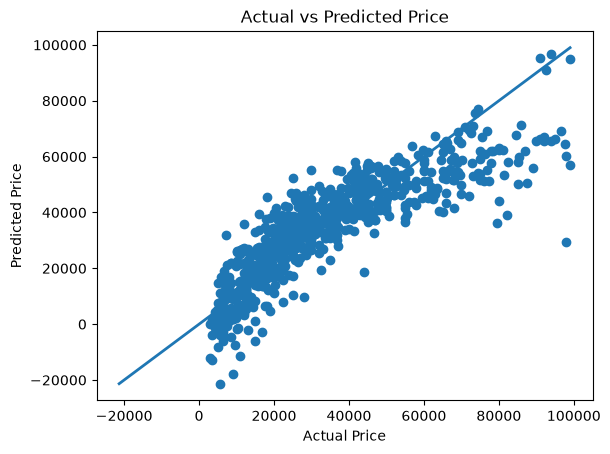

In [1688]:
plt.scatter(y_test_outlier, y_pred_outlier)


min_price = min(y_test_outlier.min(), y_pred_outlier.min())
max_price = max(y_test_outlier.max(), y_pred_outlier.max())

plt.plot(
    [min_price, max_price],
    [min_price, max_price],
    linewidth=2
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Price")

plt.show()

In [1690]:
models = [model, model2, model3, model4]
predictions = [y_pred, y_pred_new, y_pred_clean, y_pred_outlier]
actuals = [y_test, y_test_new, y_test_clean, y_test_outlier]

results = []

for i in range(len(models)):
    mae = mean_absolute_error(actuals[i], predictions[i])
    mse = mean_squared_error(actuals[i], predictions[i])
    rmse = np.sqrt(mse)
    r2 = r2_score(actuals[i], predictions[i])

    results.append([f"Model {i+1}", mae, mse, rmse, r2])

comparison = pd.DataFrame(
    results,
    columns=["Model", "MAE", "MSE", "RMSE", "R²"]
)

comparison

,Model,MAE,MSE,RMSE,R²
0,Model 1,25092.237733,1.879182e+10,137083.266410,0.080616
1,Model 2,23995.933955,1.872723e+10,136847.482354,0.083776
2,Model 3,19944.073979,7.852637e+09,88615.106811,0.185850
3,Model 4,8288.281307,1.230548e+08,11093.007331,0.733723


# Model is Best 